In [1]:
from google import genai
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
load_dotenv()

if os.environ['GEMINI_API_KEY']:
    print("key is the present")

else:
    print("key is not present or invalid") 

key is the present


In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
response = llm.invoke("Explain RAG in one short sentence").content

# Pydantc Schema 

In [6]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

class llm_schema(BaseModel):
    funny_flag: Literal["funny","not funny"] = Field(description="Whether the joke is funny or not")
    feedback: str = Field(description="Feedback on the joke")

llm_with_schema = llm.with_structured_output(llm_schema)

In [7]:
class graph_schema(TypedDict):

    topic: str
    joke: str
    funny_flag: str
    feedback: str
    max_iterations: int

 # NOde

In [9]:
def generate_node(state: graph_schema) -> graph_schema:
    

    topic = state['topic']

    if state['feedback']: # Not first iteration, generate a joke based on feedback
        response = llm.invoke(f"Please modify the following joke {state['joke']} based on the following feedback: {state['feedback']}") 
    else: # First iteration, generate a joke
        response = llm.invoke("Create only one joke about the following topic: " + topic)

    
    state['joke'] = response.content 
    return state      

In [10]:
def evaluate_node(state: graph_schema) -> graph_schema: 

    joke = state['joke']
    iteration = state['max_iterations']

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a comedy critic. Your job is to evaluate the following joke and provide feedback on how to make it funnier."),
        ("user", f"Evaluate the following joke: {joke}\nRespond with 'funny' or 'not_funny' and provide feedback if it's not funny.")
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({"joke": joke})

    state['funny_flag'] = response.funny_flag
    state['feedback'] = response.feedback
    state['max_iterations'] = iteration + 1

    return state

# Conditional Edge Function

In [11]:
def check_iteration(state: graph_schema) -> str:

    iteration = state['max_iterations']

    if iteration <= 5 and state['funny_flag'] != "funny":
        return "evaluate_node"
    else:
        return "end"


 # Create State Graph

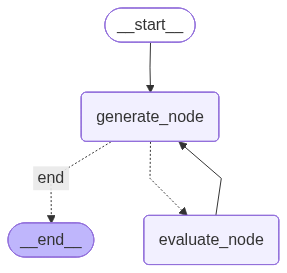

In [13]:

from langgraph.graph import StateGraph, START, END 


graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_conditional_edges("generate_node", check_iteration, {"evaluate_node": "evaluate_node", "end": END})
graph.add_edge("evaluate_node", "generate_node")
graph.add_edge("generate_node", END)

evaluator_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(evaluator_graph.get_graph().draw_mermaid_png())




In [14]:
for chunk in evaluator_graph.stream(
    {
        "topic": "Cars",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "max_iterations": 0
    },
    stream_mode="updates"
):
    print(chunk)

{'generate_node': {'topic': 'Cars', 'joke': 'Why did the car get pulled over?\n\nBecause it was *exhausted*!', 'funny_flag': '', 'feedback': '', 'max_iterations': 0}}
{'evaluate_node': {'topic': 'Cars', 'joke': 'Why did the car get pulled over?\n\nBecause it was *exhausted*!', 'funny_flag': 'not funny', 'feedback': "This is a very common and straightforward pun, making it quite predictable. While puns can be effective, this one doesn't offer any surprise or clever twist beyond the obvious wordplay. To make it funnier, consider building a more elaborate scenario around the car's 'exhaustion,' perhaps involving other car parts or a more absurd consequence of its tiredness. You could also try to misdirect the audience before delivering the pun, or layer it with another unexpected element to elevate the humor beyond a simple play on words.", 'max_iterations': 1}}


ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}